In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'smarties.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img.shape

(356, 413)

In [3]:
blurred = cv2.GaussianBlur(img, (5, 5), 0)

pairs = [(50, 100), (50, 200), (150, 250)]
edges = [cv2.Canny(blurred, low, high) for low, high in pairs]

for (low, high), e in zip(pairs, edges):
    print(f'low={low}, high={high} - edge pixels:', cv2.countNonZero(e))

low=50, high=100 - edge pixels: 3272
low=50, high=200 - edge pixels: 2993
low=150, high=250 - edge pixels: 2813


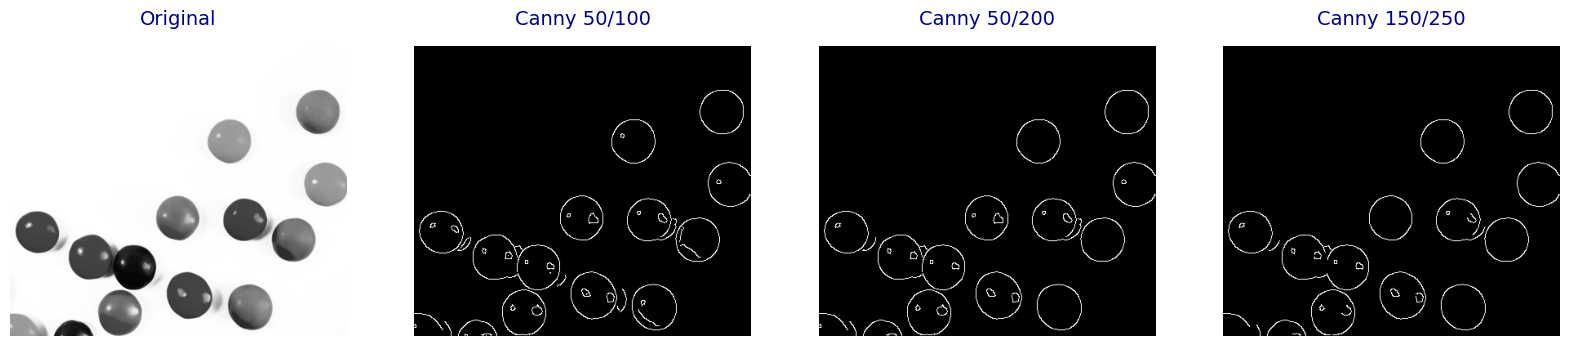

In [4]:
panels = [('Original', img)]
panels += [(f'Canny {low}/{high}', e) for (low, high), e in zip(pairs, edges)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task5_canny.png', edges[1])

True

Strong edges are the outlines of the candies. They have high contrast with the white background so they show up in all three.

Weak edges are the highlights on the candies and the faint shadows. They show with 50/100 and mostly go away at 150/250.

Missing edges: at 150/250 the outlines of the lighter candies have gaps.

Unwanted edges are small highlight shapes and shadow bits, mostly in 50/100.

Edge pixels: 3272 (50/100), 2993 (50/200), 2813 (150/250). Raising only the high threshold removes weak edges that are not connected to strong ones. Raising both removes more but also breaks real outlines. Pixels above the high threshold are kept, pixels between the two are kept only if they touch a strong edge.